<a href="https://colab.research.google.com/github/Sigurd-RW/lis4693/blob/main/final%20project/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing Packages and Importing Dataset.

In [77]:
!pip install gensim
!pip install pyldavis
!pip install nltk

In [78]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [79]:
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
from nltk.corpus import stopwords
import string
import gensim.corpora as corpora
from gensim.models import LdaModel
import pyLDAvis.gensim_models
pyLDAvis.enable_notebook()

In [80]:
import requests
import io

url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2020/2020-09-29/taylor_swift_lyrics.csv"

response = requests.get(url)
response.raise_for_status()

text = response.text

In [81]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(io.StringIO(text), on_bad_lines='skip')
print(df.head(10))

         Artist           Album                       Title   \
0  Taylor Swift   Taylor Swift                    Tim McGraw   
1  Taylor Swift   Taylor Swift               Picture to Burn   
2  Taylor Swift   Taylor Swift       Teardrops on my Guitar    
3  Taylor Swift   Taylor Swift        A Place in This World    
4  Taylor Swift   Taylor Swift                  Cold As You    
5  Taylor Swift   Taylor Swift                   The Outside   
6  Taylor Swift   Taylor Swift   Tied Together With A Smile    
7  Taylor Swift   Taylor Swift               Stay Beautiful    
8  Taylor Swift   Taylor Swift             Should’ve Said No   
9  Taylor Swift   Taylor Swift                  Mary’s Song    

                                              Lyrics  
0  He said the way my blue eyes shinx\nPut those ...  
1  State the obvious, I didn't get my perfect fan...  
2  Drew looks at me,\nI fake a smile so he won't ...  
3  I don't know what I want, so don't ask me\n'Ca...  
4  You have a way of

Cleaning the dataset and filling in missing information.

In [82]:
df.columns = df.columns.str.strip() #Ensuring variable names are clean.

album_year_map = {
    "Taylor Swift": 2006,
    "Fearless": 2008,
    "Speak Now": 2010,
    "Red": 2012,
    "1989": 2014,
    "reputation": 2017,
    "Lover": 2019,
    "folklore": 2020,
}

df["Album"] = df["Album"].str.strip() #Same for album names.

df["Year"] = df["Album"].map(album_year_map)

df["Year"] = df["Year"].astype(int) #Ensuring years are INT.
df['Lyrics'] = df['Lyrics'].str.replace('\s+', ' ', regex=True).str.strip() #Removing deadspace from lyrics.


df_text = df[["Album", "Title", "Year"]].copy()
df_text.head(1000)

,Album,Title,Year
0,Taylor Swift,Tim McGraw,2006
1,Taylor Swift,Picture to Burn,2006
2,Taylor Swift,Teardrops on my Guitar,2006
3,Taylor Swift,A Place in This World,2006
4,Taylor Swift,Cold As You,2006
...,...,...,...
127,folklore,mad woman,2020
128,folklore,epiphany,2020
129,folklore,betty,2020
130,folklore,peace,2020


In [83]:
print(df["Year"].unique())
print(df["Year"].dtype) #Ensuring INT for analysis calculations.

[2006 2008 2010 2012 2014 2017 2019 2020]
int64


In [84]:
df_text = df[["Lyrics"]].copy()
df_text.head(10)

,Lyrics
0,He said the way my blue eyes shinx Put those G...
1,"State the obvious, I didn't get my perfect fan..."
2,"Drew looks at me, I fake a smile so he won't s..."
3,"I don't know what I want, so don't ask me 'Cau..."
4,You have a way of coming easily to me And when...
5,I didn't know what I would find When I went lo...
6,Seems the only one who doesn't see your beauty...
7,Cory's eyes are like a jungle He smiles; it's ...
8,It's strange to think the songs we used to sin...
9,"She said ""I was seven, and you were nine I loo..."


In [85]:
docs = df.Lyrics.tolist()
print(docs[0])

He said the way my blue eyes shinx Put those Georgia stars to shame that night I said: "That's a lie." Just a boy in a Chevy truck That had a tendency of gettin' stuck On back roads at night And I was right there beside him all summer long And then the time we woke up to find that summer had gone But when you think "Tim McGraw" I hope you think my favorite song The one we danced to all night long The moon like a spotlight on the lake When you think happiness I hope you think "that little black dress" Think of my head on your chest And my old faded blue jeans When you think Tim McGraw I hope you think of me September saw a month of tears And thankin' God that you weren't here To see me like that But in a box beneath my bed Is a letter that you never read From three summers back It's hard not to find it all a little bitter sweet And lookin' back on all of that, it's nice to believe But when you think "Tim McGraw" I hope you think my favorite song The one we danced to all night long The m

Adding Stopwords.

In [86]:
stop_words = stopwords.words('english')

In [87]:
def clean_doc(doc):
    no_punct = ''
    for c in doc:
        if c not in string.punctuation:
            no_punct = no_punct+c
    # with list comprehension
    # no_punct = ''.join([c for c in doc if c not in string.punctuation])

    words = no_punct.lower().split()

    final_words = []
    for word in words:
        if word not in stop_words:
            final_words.append(word)

    # with list comprehension
    # final_words = [word for word in words if word not in stop_words]

    return final_words

In [88]:
df['Lyrics'] = df['Lyrics'].str.replace("[^a-zA-Z#]", "   ")
df['Lyrics'] = df['Lyrics'].str.casefold()
print(df.head(10))

          Artist         Album                        Title  \
0  Taylor Swift   Taylor Swift                   Tim McGraw   
1  Taylor Swift   Taylor Swift              Picture to Burn   
2  Taylor Swift   Taylor Swift      Teardrops on my Guitar    
3  Taylor Swift   Taylor Swift       A Place in This World    
4  Taylor Swift   Taylor Swift                 Cold As You    
5  Taylor Swift   Taylor Swift                  The Outside   
6  Taylor Swift   Taylor Swift  Tied Together With A Smile    
7  Taylor Swift   Taylor Swift              Stay Beautiful    
8  Taylor Swift   Taylor Swift            Should’ve Said No   
9  Taylor Swift   Taylor Swift                 Mary’s Song    

                                              Lyrics  Year  
0  he said the way my blue eyes shinx put those g...  2006  
1  state the obvious, i didn't get my perfect fan...  2006  
2  drew looks at me, i fake a smile so he won't s...  2006  
3  i don't know what i want, so don't ask me 'cau...  2006  
4

In [89]:

## Adding custom stopwords

custom_stopwords = set([
    'know', 'think', 'dont', 'im', 'like', 'youre',
    'oh', 'gonna', 'one', 'want', 'see', 'back',
    'yet', 'say', 'york', 'shake', 'ill', 'cause',
    'ha', 'would', 'go', 'got', 'ever', 'id', 'could',
    'cant', 'come', 'wanna', 'ooh', 'ohoh', 'mean',
    'yeah', 'thats', 'let', 'shes', 'last', 'mmm',
    'take', 'said', 'get', 'call', 'knows', 'youll',
    'ive', 'shouldve', 'still', 'ah', 'tell',
    'uhey',
    'never', 'time', 'little', 'way', 'right', 'baby', 'whoa', 'oohah'
])

stop_words.extend(custom_stopwords)
print(f"New stopwords added: {custom_stopwords}")

New stopwords added: {'id', 'yeah', 'ah', 'right', 'ive', 'back', 'gonna', 'take', 'wanna', 'let', 'shake', 'ooh', 'got', 'come', 'last', 'tell', 'mean', 'uhey', 'get', 'go', 'shouldve', 'cause', 'yet', 'little', 'oohah', 'youre', 'ever', 'whoa', 'think', 'ohoh', 'said', 'baby', 'know', 'way', 'one', 'see', 'could', 'call', 'york', 'cant', 'im', 'knows', 'ill', 'dont', 'ha', 'oh', 'say', 'mmm', 'youll', 'never', 'thats', 'time', 'still', 'like', 'want', 'would', 'shes'}


Creating Corpus.

In [90]:
cleaned_docs = [clean_doc(doc) for doc in docs]
id2word = corpora.Dictionary(cleaned_docs)
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

print("Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.")

cleaned_with_custom_stopwords = clean_doc(docs[0])
print("\nOriginal document (first one):")
print(docs[0])
print("\nCleaned document with custom stopwords:")
print(cleaned_with_custom_stopwords)

Cleaning process, ID-Word Index, and Corpus have been regenerated with new stopwords.

Original document (first one):
He said the way my blue eyes shinx Put those Georgia stars to shame that night I said: "That's a lie." Just a boy in a Chevy truck That had a tendency of gettin' stuck On back roads at night And I was right there beside him all summer long And then the time we woke up to find that summer had gone But when you think "Tim McGraw" I hope you think my favorite song The one we danced to all night long The moon like a spotlight on the lake When you think happiness I hope you think "that little black dress" Think of my head on your chest And my old faded blue jeans When you think Tim McGraw I hope you think of me September saw a month of tears And thankin' God that you weren't here To see me like that But in a box beneath my bed Is a letter that you never read From three summers back It's hard not to find it all a little bitter sweet And lookin' back on all of that, it's nice 

In [91]:
cleaned_docs = [clean_doc(doc) for doc in docs]

In [92]:
id2word = corpora.Dictionary(cleaned_docs)

In [93]:
id2word[250]

'knew'

In [94]:
corpus = [id2word.doc2bow(cleaned_doc) for cleaned_doc in cleaned_docs]

In [95]:
print(corpus[0])

[(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 3), (6, 5), (7, 1), (8, 1), (9, 3), (10, 1), (11, 2), (12, 1), (13, 3), (14, 2), (15, 3), (16, 3), (17, 2), (18, 2), (19, 2), (20, 1), (21, 1), (22, 1), (23, 3), (24, 1), (25, 3), (26, 10), (27, 3), (28, 2), (29, 1), (30, 2), (31, 2), (32, 3), (33, 1), (34, 6), (35, 1), (36, 2), (37, 1), (38, 5), (39, 3), (40, 1), (41, 2), (42, 1), (43, 2), (44, 1), (45, 1), (46, 1), (47, 2), (48, 1), (49, 1), (50, 1), (51, 1), (52, 3), (53, 2), (54, 1), (55, 2), (56, 1), (57, 1), (58, 2), (59, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1), (66, 1), (67, 1), (68, 6), (69, 1), (70, 1), (71, 1), (72, 1)]


In [96]:
for num in corpus[0]:
    num = num[0]
    print(f"{num}\t{id2word[num]}")

0	bed
1	believe
2	beneath
3	beside
4	bitter
5	black
6	blue
7	box
8	boy
9	chest
10	chevy
11	danced
12	doorstep
13	dress
14	eyes
15	faded
16	favorite
17	find
18	first
19	georgia
20	gettin
21	god
22	gone
23	happiness
24	hard
25	head
26	hope
27	jeans
28	lake
29	left
30	letter
31	lie
32	long
33	lookin
34	mcgraw
35	month
36	moon
37	nice
38	night
39	old
40	place
41	put
42	radio
43	read
44	roads
45	saw
46	september
47	shame
48	shined
49	shinx
50	since
51	someday
52	song
53	spotlight
54	standin
55	stars
56	street
57	stuck
58	summer
59	summers
60	sweet
61	takes
62	tears
63	tendency
64	thankin
65	theres
66	thing
67	three
68	tim
69	truck
70	turn
71	werent
72	woke


Creating Topic Analysis model.

In [97]:
lda_10 = LdaModel(corpus=corpus, id2word=id2word, num_topics=10)

In [98]:
topics = lda_10.get_document_topics(corpus)
len(topics)

132

In [99]:
for topic_id, score in topics[0]:
    print(f"({topic_id}, {float(score)})")

(0, 0.9934750199317932)


In [100]:
print(docs[0])

He said the way my blue eyes shinx Put those Georgia stars to shame that night I said: "That's a lie." Just a boy in a Chevy truck That had a tendency of gettin' stuck On back roads at night And I was right there beside him all summer long And then the time we woke up to find that summer had gone But when you think "Tim McGraw" I hope you think my favorite song The one we danced to all night long The moon like a spotlight on the lake When you think happiness I hope you think "that little black dress" Think of my head on your chest And my old faded blue jeans When you think Tim McGraw I hope you think of me September saw a month of tears And thankin' God that you weren't here To see me like that But in a box beneath my bed Is a letter that you never read From three summers back It's hard not to find it all a little bitter sweet And lookin' back on all of that, it's nice to believe But when you think "Tim McGraw" I hope you think my favorite song The one we danced to all night long The m

In [101]:
print("\n--- Top words for all topics in lda_10 model ---")
for i in range(lda_10.num_topics):
    terms = lda_10.get_topic_terms(i, 5)
    print(f"Topic {i}:")
    for num, prob in terms:
        print(f"  {id2word[num]} (probability: {prob:.4f})")
    print()


--- Top words for all topics in lda_10 model ---
Topic 0:
  love (probability: 0.0220)
  look (probability: 0.0127)
  made (probability: 0.0106)
  woods (probability: 0.0099)
  clear (probability: 0.0097)

Topic 1:
  love (probability: 0.0080)
  long (probability: 0.0078)
  break (probability: 0.0069)
  stay (probability: 0.0067)
  trouble (probability: 0.0060)

Topic 2:
  play (probability: 0.0103)
  love (probability: 0.0094)
  hate (probability: 0.0090)
  girl (probability: 0.0080)
  fake (probability: 0.0079)

Topic 3:
  wish (probability: 0.0417)
  knew (probability: 0.0095)
  love (probability: 0.0084)
  night (probability: 0.0068)
  long (probability: 0.0066)

Topic 4:
  red (probability: 0.0165)
  starlight (probability: 0.0106)
  made (probability: 0.0104)
  look (probability: 0.0095)
  love (probability: 0.0093)

Topic 5:
  man (probability: 0.0158)
  new (probability: 0.0128)
  made (probability: 0.0121)
  wonderland (probability: 0.0103)
  look (probability: 0.0099)

Topic

Visualizing Topic Analysis.

In [102]:
topic_data = []
target_topic_ids = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for topic_id in target_topic_ids:
    topic_terms = lda_10.show_topic(topic_id, topn=10)

    for word, prob in topic_terms:
        topic_data.append({
            'Topic ID': topic_id,
            'Word': word,
            'Probability': prob
        })

df_topic_words = pd.DataFrame(topic_data)
print("DataFrame 'df_topic_words' created successfully with topic words and probabilities.")
print(df_topic_words.head())


DataFrame 'df_topic_words' created successfully with topic words and probabilities.
   Topic ID   Word  Probability
0         0   love     0.022028
1         0   look     0.012677
2         0   made     0.010551
3         0  woods     0.009918
4         0  clear     0.009654


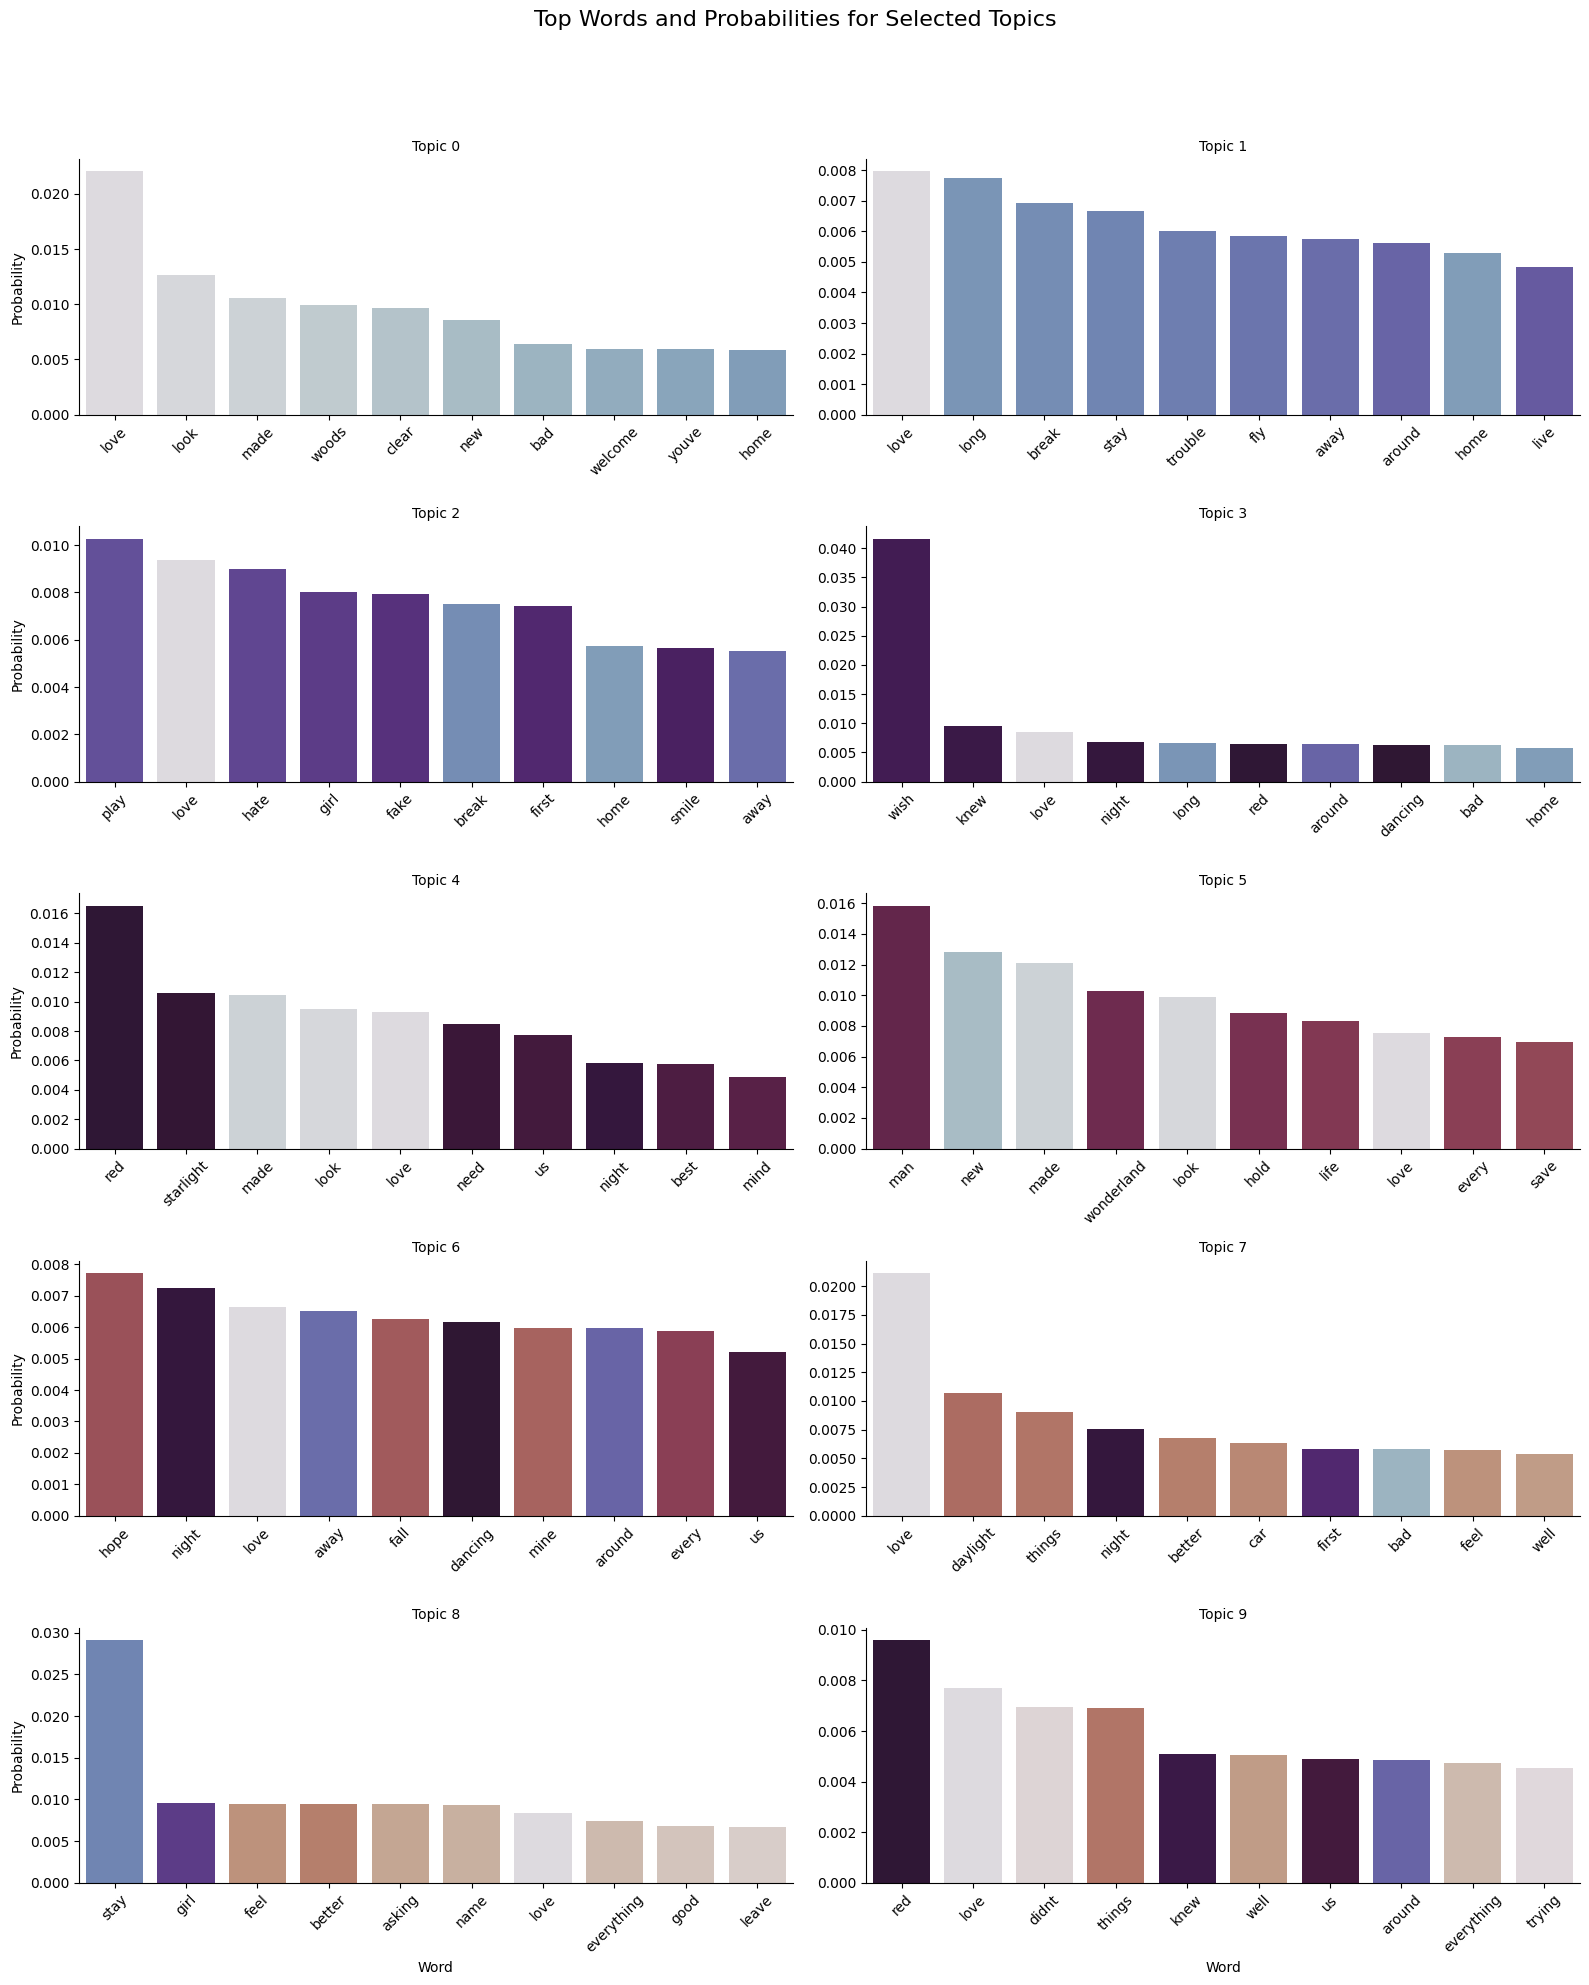

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the facet bar plot
g = sns.catplot(data=df_topic_words, x='Word', y='Probability', col='Topic ID', col_wrap=2, kind='bar',
                height=4, aspect=2, hue='Word', legend=False, palette='twilight', sharex=False, sharey=False)

# Customize the plot
g.set_axis_labels("Word", "Probability")
g.set_titles("Topic {col_name}")

# Rotate x-axis labels for better readability
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.tick_params(axis='x', labelbottom=True)

plt.suptitle('Top Words and Probabilities for Selected Topics', y=1.02, fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [104]:
vis = pyLDAvis.gensim_models.prepare(lda_10, corpus, id2word, mds="mmds", R=20)

In [105]:
vis

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.078955  0.061221       1        1  21.738753
7      0.020713  0.042985       2        1  17.173549
6     -0.055228 -0.066571       3        1  12.158931
8     -0.011558  0.111753       4        1  12.035493
3      0.019426 -0.112842       5        1   9.065749
5     -0.109968  0.087972       6        1   7.192742
1      0.019263 -0.042346       7        1   5.858724
4     -0.104741 -0.027214       8        1   5.194434
2      0.100796 -0.044559       9        1   5.174601
9      0.042340 -0.010399      10        1   4.407024, topic_info=        Term       Freq      Total Category  logprob  loglift
174     wish  79.000000  79.000000  Default  20.0000  20.0000
327     stay  89.000000  89.000000  Default  19.0000  19.0000
1443     red  42.000000  42.000000  Default  18.0000  18.0000
1784   woods  40.000000  40.000000  Default  17.0000  17.0000
430      man  32.000000  32.000000  Default  16.0000  16.0000
...      ...        ...        ...      ...      ...      ...
243   wanted   2.251440  23.886293  Topic10  -5.7827   0.7602
14      eyes   2.847206  56.039372  Topic10  -5.5479   0.1423
174     wish   3.106094  79.339519  Topic10  -5.4609  -0.1184
18     first   2.647418  58.858237  Topic10  -5.6207   0.0204
131    break   2.472635  50.027770  Topic10  -5.6890   0.1147

[482 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
1807      2  0.256947          2
1807      5  0.513894          2
2501      4  0.310667  afterglow
2501      8  0.310667  afterglow
203       1  0.136308       aint
...     ...       ...        ...
247       6  0.043848      youve
247       7  0.065772      youve
247       8  0.021924      youve
247       9  0.065772      youve
247      10  0.021924      youve

[1632 rows x 3 columns], R=20, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 8, 7, 9, 4, 6, 2, 5, 3, 10])

### Performing Sentiment Analysis

In [106]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [107]:
df1 = pd.DataFrame()
df1['ObjectId'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [108]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df.iterrows():
    scores = sid.polarity_scores(row['Lyrics']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'Title': row['Title'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Create a DataFrame from the list of dictionaries after the loop
t_df_all_types = pd.DataFrame(all_scores_list)

# Filter for compound sentiment and remove duplicates
t_df_cleaned = t_df_all_types[t_df_all_types.sentiment_type == 'compound'].drop_duplicates()

print(t_df_cleaned.head(10))

Processing sentiment analysis...
                          Title sentiment_type  sentiment_score
3                    Tim McGraw       compound           0.9974
7               Picture to Burn       compound          -0.9980
11      Teardrops on my Guitar        compound           0.9679
15       A Place in This World        compound           0.8943
19                 Cold As You        compound          -0.9299
23                  The Outside       compound          -0.9302
27  Tied Together With A Smile        compound          -0.8336
31              Stay Beautiful        compound           0.9991
35            Should’ve Said No       compound          -0.8271
39                 Mary’s Song        compound           0.9850


In [109]:
df_output = pd.merge(df, t_df_cleaned, on='Title', how='inner')
print(df_output.head(10))

          Artist         Album                        Title  \
0  Taylor Swift   Taylor Swift                   Tim McGraw   
1  Taylor Swift   Taylor Swift              Picture to Burn   
2  Taylor Swift   Taylor Swift      Teardrops on my Guitar    
3  Taylor Swift   Taylor Swift       A Place in This World    
4  Taylor Swift   Taylor Swift                 Cold As You    
5  Taylor Swift   Taylor Swift                  The Outside   
6  Taylor Swift   Taylor Swift  Tied Together With A Smile    
7  Taylor Swift   Taylor Swift              Stay Beautiful    
8  Taylor Swift   Taylor Swift            Should’ve Said No   
9  Taylor Swift   Taylor Swift                 Mary’s Song    

                                              Lyrics  Year sentiment_type  \
0  he said the way my blue eyes shinx put those g...  2006       compound   
1  state the obvious, i didn't get my perfect fan...  2006       compound   
2  drew looks at me, i fake a smile so he won't s...  2006       compound  

In [111]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment_scores(text):
    return analyzer.polarity_scores(text)

df['sentiment_scores'] = df['Lyrics'].apply(get_sentiment_scores)
df[['Lyrics', 'sentiment_scores']].head()

,Lyrics,sentiment_scores
0,he said the way my blue eyes shinx put those g...,"{'neg': 0.036, 'neu': 0.761, 'pos': 0.204, 'co..."
1,"state the obvious, i didn't get my perfect fan...","{'neg': 0.313, 'neu': 0.62, 'pos': 0.067, 'com..."
2,"drew looks at me, i fake a smile so he won't s...","{'neg': 0.03, 'neu': 0.843, 'pos': 0.126, 'com..."
3,"i don't know what i want, so don't ask me 'cau...","{'neg': 0.083, 'neu': 0.798, 'pos': 0.119, 'co..."
4,you have a way of coming easily to me and when...,"{'neg': 0.154, 'neu': 0.732, 'pos': 0.114, 'co..."


Visualizing Sentiment Analysis.

In [112]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,132.000000
mean,0.471286
std,0.813098
min,-0.999700
25%,-0.127825
50%,0.973850
75%,0.995725
max,0.999900


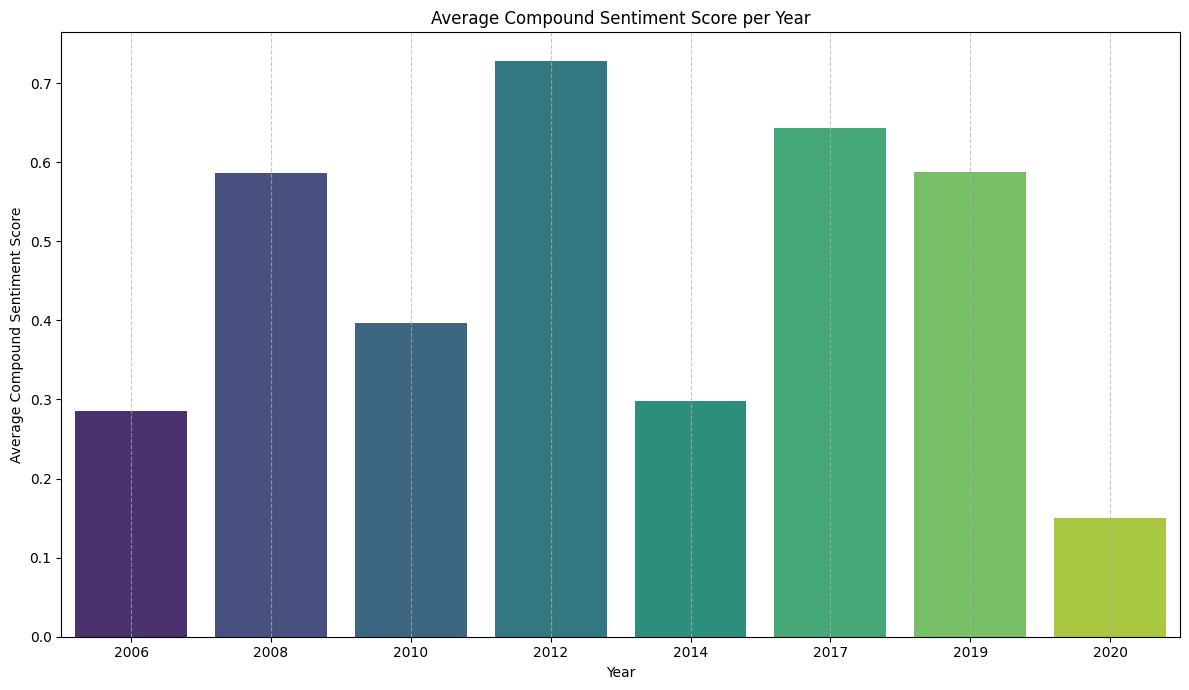

In [113]:
df_output['compound_sentiment'] = df_output['sentiment_score']

album_sentiment = (
    df_output.groupby('Year')['compound_sentiment']
    .mean()
    .reset_index()
    .sort_values('Year')
)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

sns.barplot(
    x='Year',
    y='compound_sentiment',
    data=album_sentiment,
    palette='viridis'
)

plt.title('Average Compound Sentiment Score per Year')
plt.xlabel('Year')
plt.ylabel('Average Compound Sentiment Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, '2006'),
  Text(1, 0, '2008'),
  Text(2, 0, '2010'),
  Text(3, 0, '2012'),
  Text(4, 0, '2014'),
  Text(5, 0, '2017'),
  Text(6, 0, '2019'),
  Text(7, 0, '2020')])

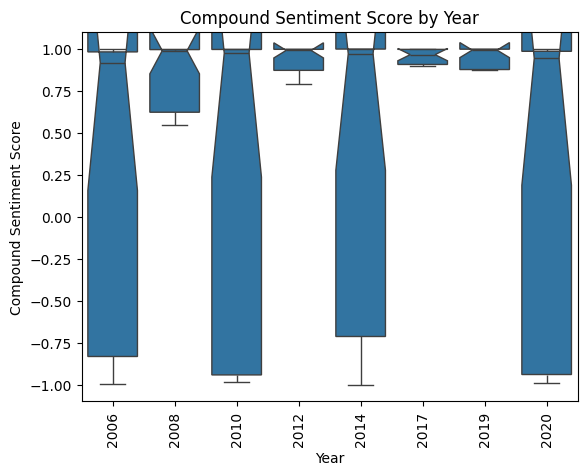

In [114]:
import seaborn as sns
#create seaborn boxplots by group
sns.boxplot(x='Year', y='compound_sentiment', notch = True,
            data=df_output, showfliers=False).set(title='Compound Sentiment Score by Year')
#modify axis labels
plt.xlabel('Year')
plt.ylabel('Compound Sentiment Score')
plt.xticks(rotation=90)